## Список картинок, импорт OCR

In [18]:
import os
import sys
from IPython.display import Image as DisplayImage, display
from PIL import Image, ImageDraw

sys.path.append(os.path.abspath('..'))

In [13]:
memes = [
    os.path.join("../ocr_research/memes", f) 
    for f in os.listdir("../ocr_research/memes") 
    if f.endswith(".jpg")
]

In [14]:
from app.ocr_module import OCRService

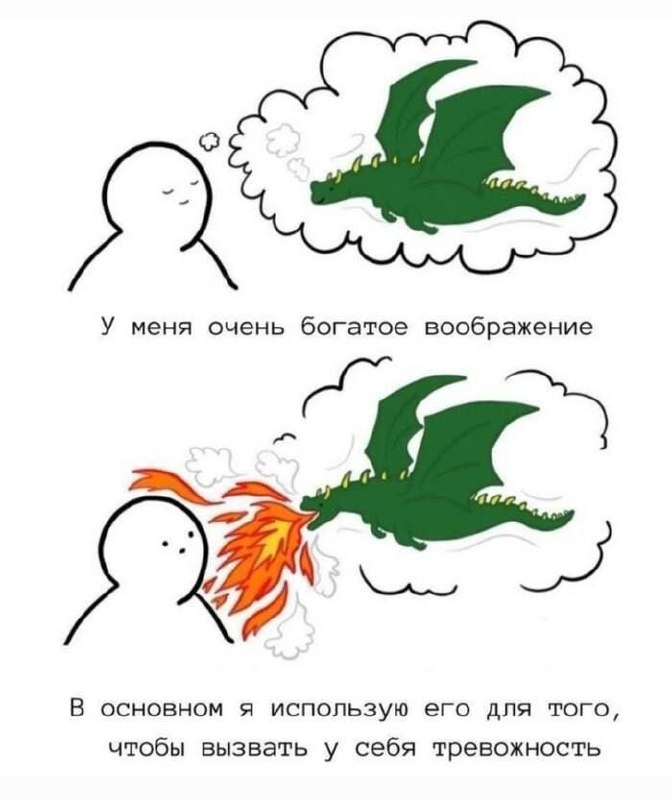

Recognizing Text: 100%|██████████| 4/4 [00:07<00:00,  1.89s/it]

OCRResult(blocks=[TextBlock(coords=(128, 312, 595, 341), text='меня очень богатое воображение', confidence=0.9997968599200249), TextBlock(coords=(66, 693, 622, 723), text='В основном я использую его для того,', confidence=0.9997020003042723), TextBlock(coords=(104, 731, 604, 764), text='чтобы вызвать у себя тревожность', confidence=0.9997718614690444)], full_text='меня очень богатое воображение\nВ основном я использую его для того,\nчтобы вызвать у себя тревожность')


In [15]:
service = OCRService()

display(DisplayImage(filename=memes[0], width=300))
print(service.process(Image.open(memes[0])))

## Убираем текст по координатам найденных блоков

In [37]:
from iopaint.model_manager import ModelManager
from iopaint.schema import InpaintRequest
import numpy as np
import cv2

Создадим маску по координатам блоков:

Detecting bboxes:   0%|          | 0/1 [00:00<?, ?it/s]

Recognizing Text: 100%|██████████| 4/4 [00:18<00:00,  4.58s/it]


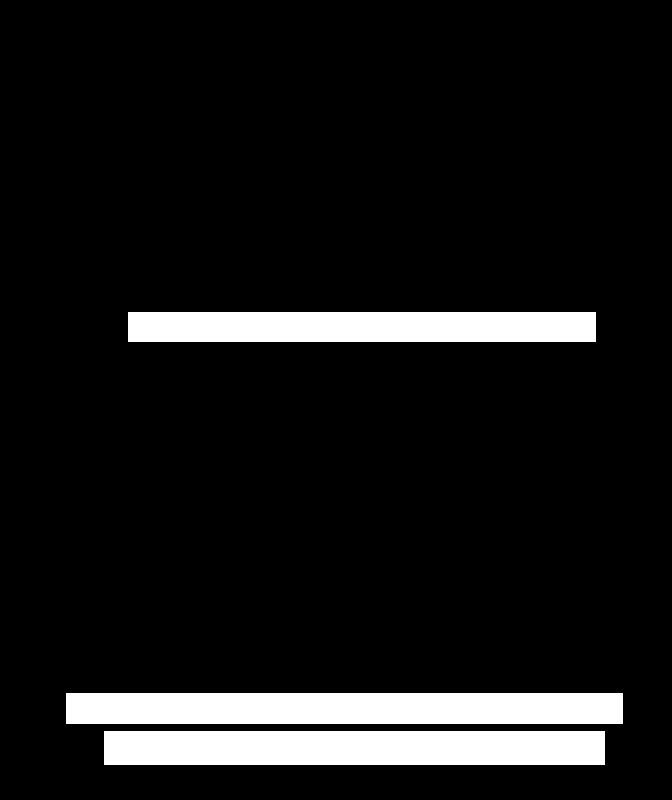

In [21]:
ocr_result = service.process(Image.open(memes[0]))
img = Image.open(memes[0])

mask = Image.new("L", img.size, 0)
draw = ImageDraw.Draw(mask)

for block in ocr_result.blocks:
    x1, y1, x2, y2 = block.coords
    draw.rectangle([x1, y1, x2, y2], fill=255)

display(mask)

2026-04-12 18:30:52.612 | INFO     | iopaint.model_manager:init_model:47 - Loading model: lama
2026-04-12 18:30:52.614 | INFO     | iopaint.helper:load_jit_model:107 - Loading model from: C:\Users\dielo/.cache\torch\hub\checkpoints\big-lama.pt


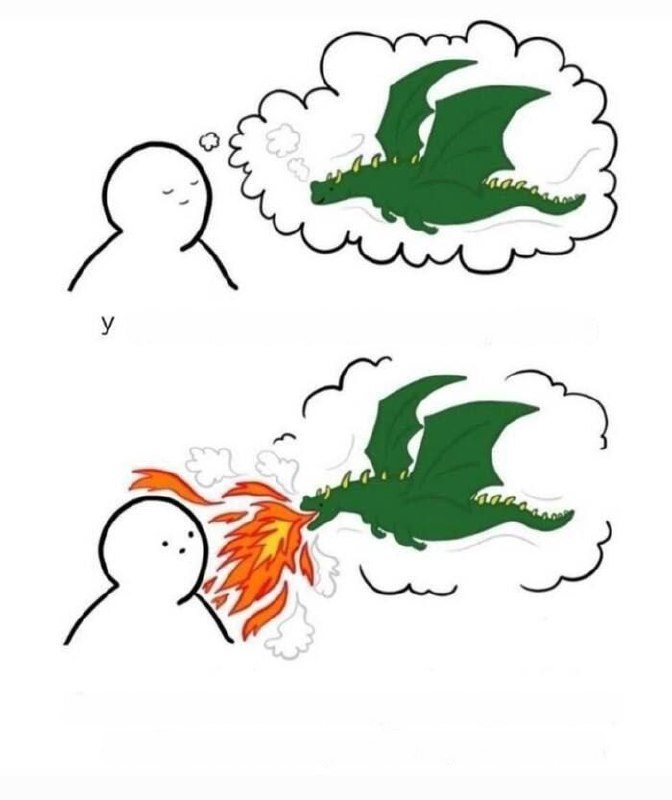

In [39]:
model = ModelManager(name="lama", device="cpu")

img_np = np.array(img)
mask_np = np.array(mask)

config = InpaintRequest()

result = model(
    image=img_np, 
    mask=mask_np, 
    config=config
)

result_img = Image.fromarray(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

display(result_img)

Соберем функцию, которая принимает картинку и возвращает картинку без текста:

In [40]:
def clean_img(img_path, show=False):
    img = Image.open(img_path)
    ocr_result = service.process(img)

    mask = Image.new("L", img.size, 0)
    draw = ImageDraw.Draw(mask)

    for block in ocr_result.blocks:
        x1, y1, x2, y2 = block.coords
        draw.rectangle([x1, y1, x2, y2], fill=255)

    model = ModelManager(name="lama", device="cpu")

    img_np = np.array(img)
    mask_np = np.array(mask)

    config = InpaintRequest()

    result = model(
        image=img_np, 
        mask=mask_np, 
        config=config
    )

    result_img = Image.fromarray(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))

    if show:
        new_width = 300

        w_percent = new_width / result_img.width
        new_height = int(result_img.height * w_percent)

        img_resized = result_img.resize((new_width, new_height))

        display(img_resized)

    return result_img

Recognizing Text: 100%|██████████| 3/3 [00:07<00:00,  2.42s/it]
2026-04-12 18:42:10.763 | INFO     | iopaint.model_manager:init_model:47 - Loading model: lama
2026-04-12 18:42:10.764 | INFO     | iopaint.helper:load_jit_model:107 - Loading model from: C:\Users\dielo/.cache\torch\hub\checkpoints\big-lama.pt
2026-04-12 18:42:11.323 | INFO     | iopaint.model.base:__call__:97 - Run crop strategy


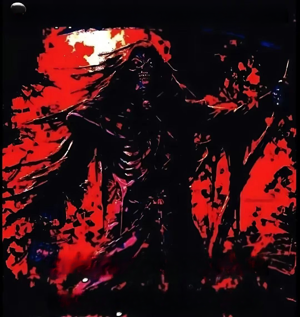

In [45]:
c_img = clean_img(memes[5], True)

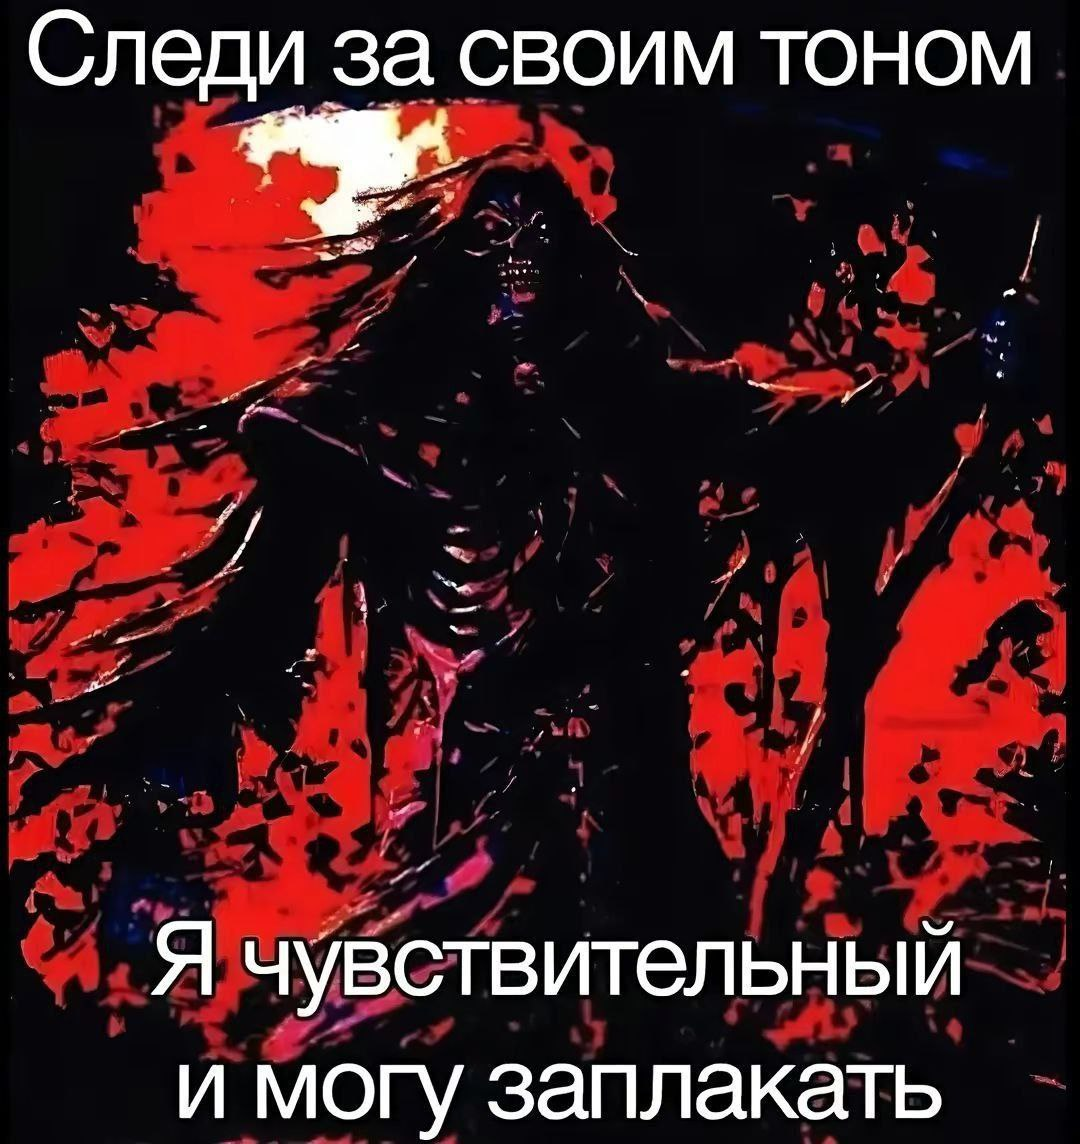

In [46]:
display(DisplayImage(filename=memes[5], width=300))

Для ускорения дальнейшей работы с влм и ллм сохраним результаты обработки OCR, распознанный текст и изображение без текста

In [4]:
from ollama import chat

In [ ]:
promt_moondream = """
Provide a visual description of this image or meme. 
Describe the sequence of events or changes visible in the image, frame by frame if applicable (From left to right, from top to bottom)
For each scene, note the main subjects, their actions, and interactions. 
Do not include emotions, context, or humor. 
Very important: ignore any text in the image, do not translate, read or tell it is there, including labels and text which is a part of the picture
"""

In [6]:
def show_result_moondream(img_path):

    response = chat(
        model='moondream:v2',
        messages=[
            {
                'role': 'user',
                'content': promt_moondream,
                'images': [img_path]
            }
        ]
    )

    display(DisplayImage(filename=img_path, width=300))
    print(response.message.content)

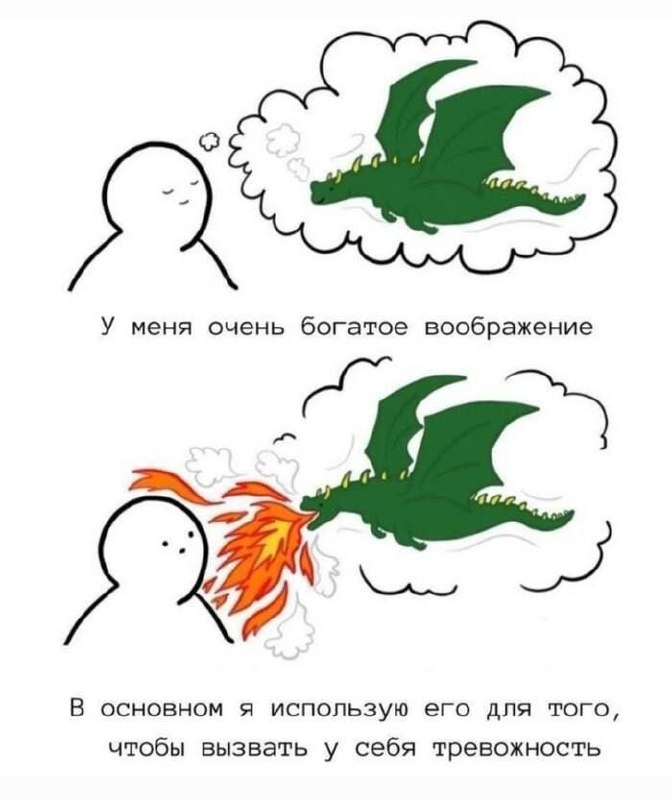


The image presents a series of drawings depicting a person's thought process as they imagine themselves with a dragon breathing fire at them. The first drawing shows a person with their eyes closed and a thought bubble above their head containing the dragon. The second drawing depicts the same person with an open mouth, ready to take in the dragon's breath. The third drawing shows the person with their mouth wide open, attempting to breathe along with the dragon.


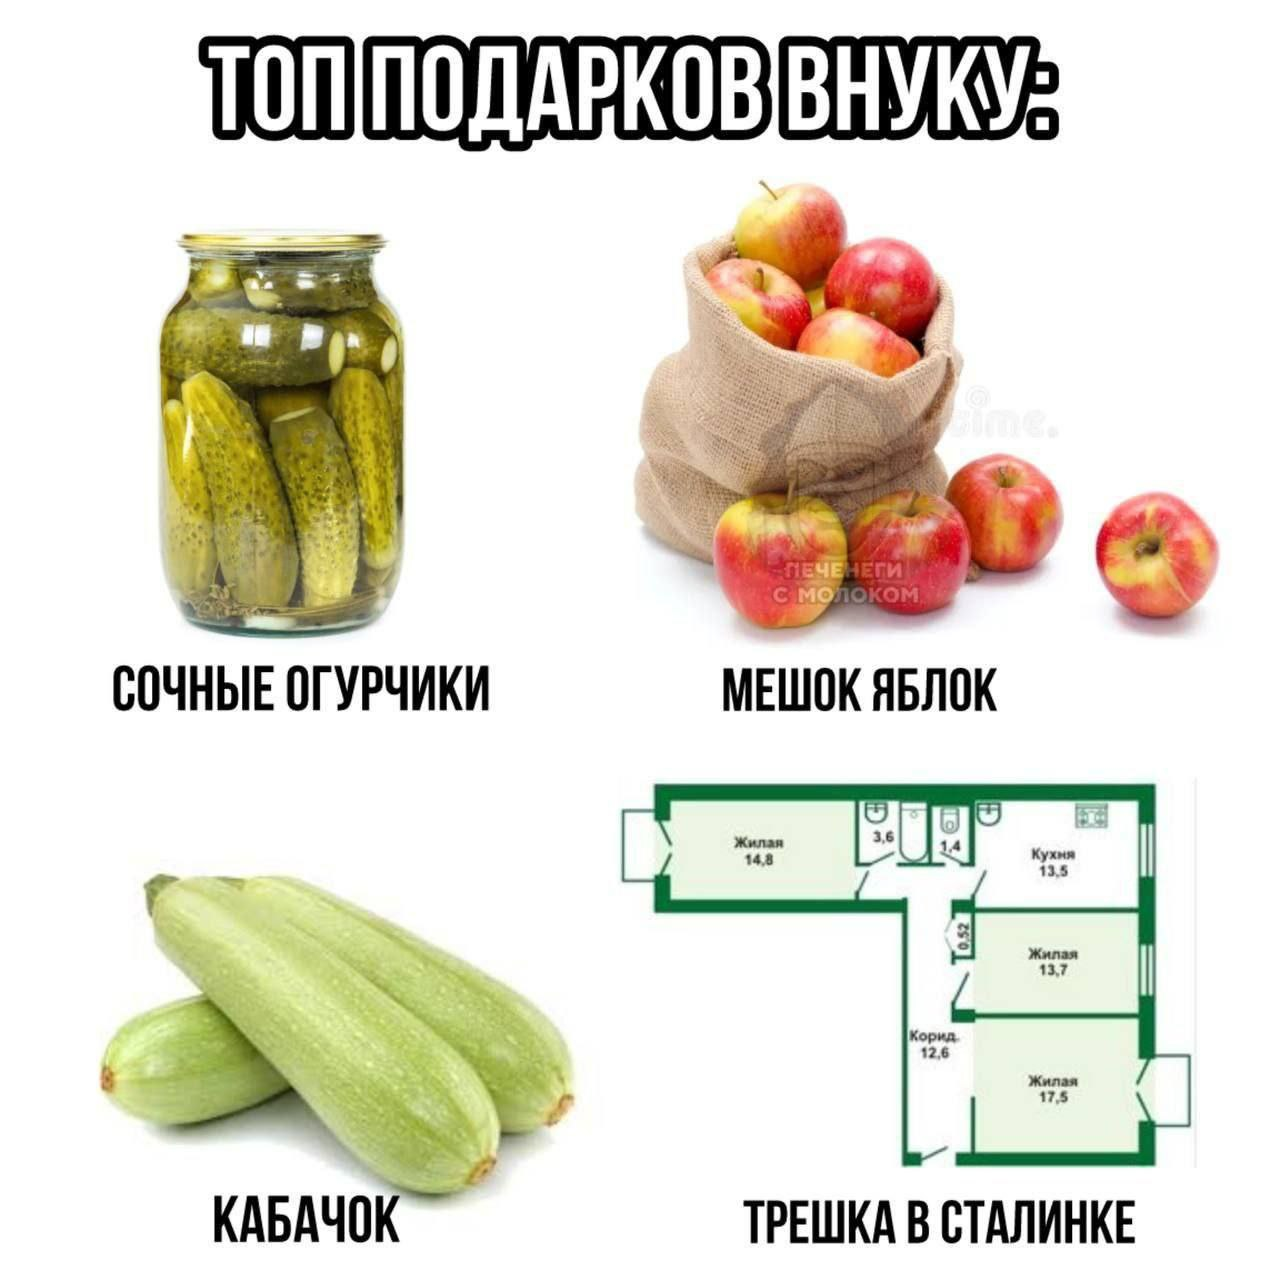


 1. A jar of pickles with a label that says "Объект картинков" (pickle) and "Споследовательно для извлечения картинков".


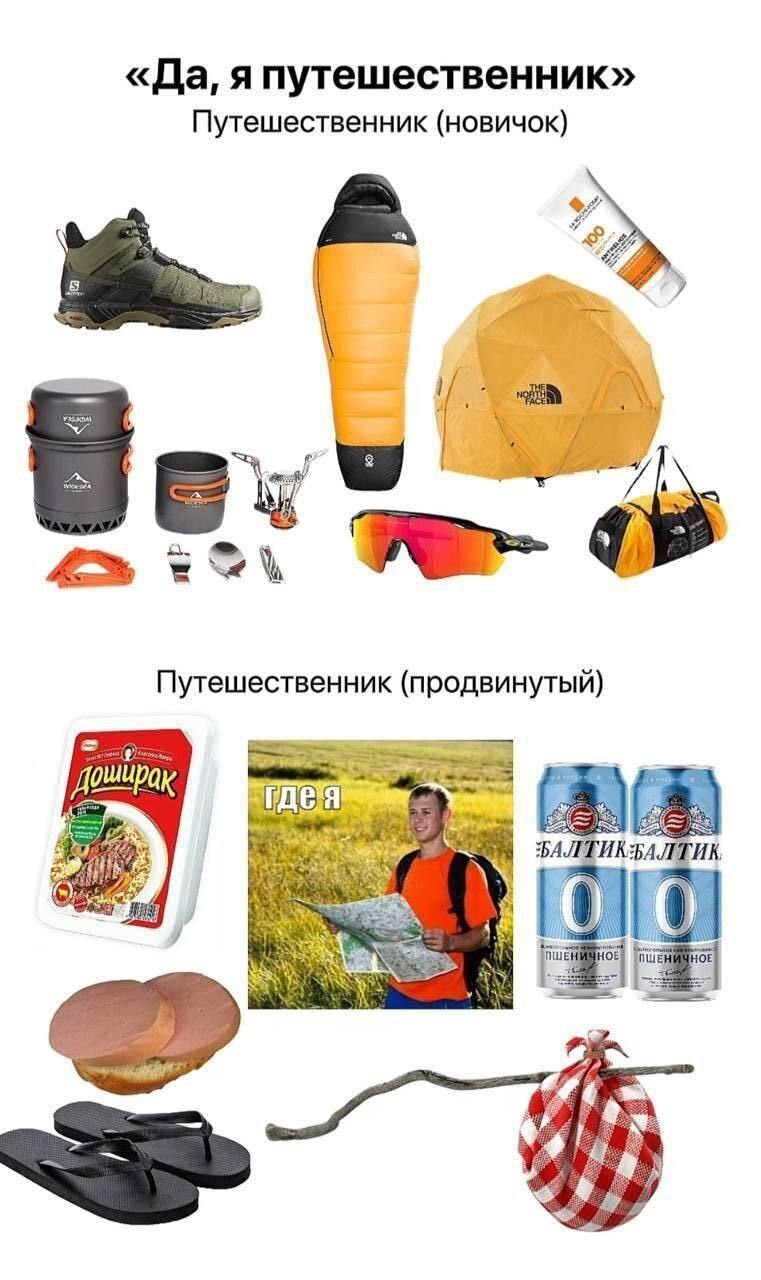


 [0.12, 0.13, 0.5, 0.31]


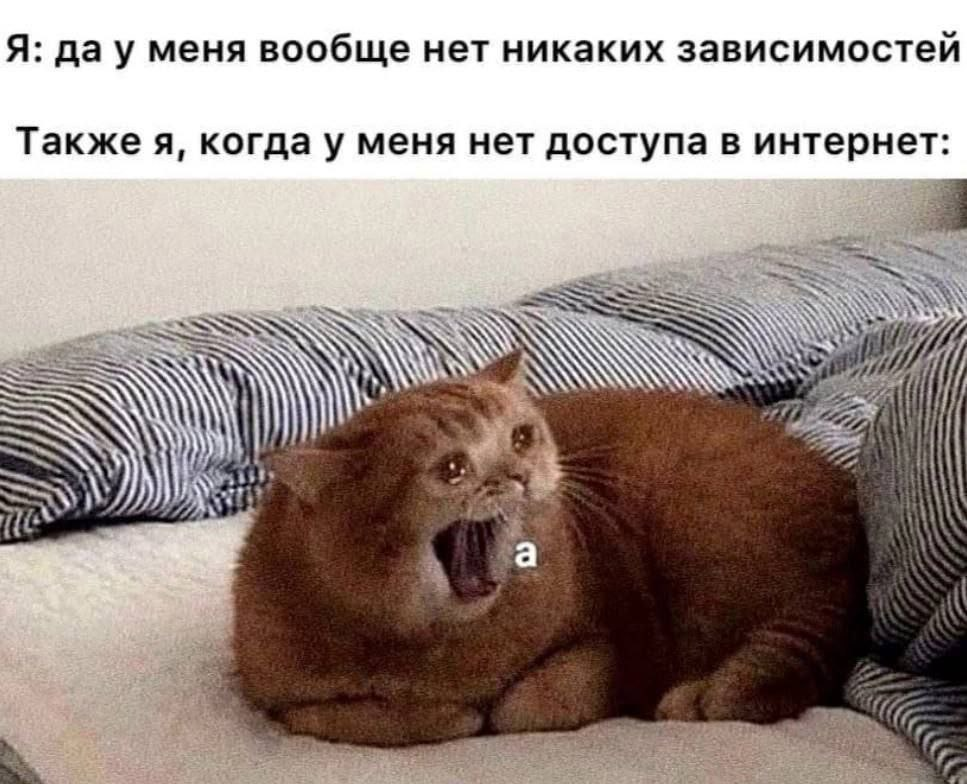


The image shows a cat sitting on top of a bed with its mouth open wide as if it's meowing. The cat appears to be wearing a collar and has an "a" tag attached to it. The background features a striped comforter and pillows, creating a cozy atmosphere for the feline.


KeyboardInterrupt: 

In [9]:
for img in memes[:10]:
    show_result_moondream(img)